# Frontier benchmark — reproduce a classification run (§14.11 protocol)

**What this reproduces:** one canonical frontier-benchmark run — the 9-method, 5-fold, seed-42
protocol of master-report §14.11 (TabPFN + CatBoost + LightGBM + XGBoost + RF + LR + 3 GLMs,
scored on log loss / AUC / Brier / PR-AUC / top-decile lift, with parameter counts and the
D3 beyond-SE Pareto rule).

**How it works:** this notebook does *not* reimplement the experiment. It calls the exact
script that produced the committed results — `scripts/eval/insurance_benchmark_v1/run_frontier_benchmark.py` —
so the code run here is byte-for-byte the code that ran the research.

**Requirements:**
- Kernel must be the benchmark venv (`.venv-ta`, Python 3.12, tabpfn-client 0.3.3) — see `notebooks/reproducibility/README.md`
- Auth: the preflight cell offers one-click **browser login** (opens the Prior Labs login page; saves the token to the gitignored repo-root `.env`). Alternatively set `TABPFN_API_KEY` manually

**Cost:** this notebook runs ONE dataset (`coil2000`, 9,822 rows — the smallest). A few minutes.
The full 6-dataset suite takes hours (TabPFN is a hosted API; the 163K-row sets dominate).

**⚠ Warning:** seed 42 is the *canonical* seed. Re-running it **overwrites the committed**
`frontier_results_coil2000.csv` / `frontier_plot_coil2000.png`. For exploration use `--seed 7`
(writes `_seed7` files, never clobbers canonical results — see the last cell).

## Shipped with executed evidence

This notebook ships with its evidence cells already executed — the tables and the frontier plot below are the committed canonical results. Read the outputs to follow along, or re-run any cell: everything except the experiment cell works instantly from the committed files (`frontier_results_coil2000.csv`, `frontier_plot_coil2000.png`).

**The one optional cell is the 'run the experiment' cell (tagged `optional`):** it re-runs the canonical script against the hosted API — a few minutes, costs credits, and **overwrites the committed CSVs** (seed 42 is canonical). Every other cell is safe and cheap to re-run.

In [1]:
from pathlib import Path
import sys

# Locate the repo root regardless of where Jupyter was launched from.
ROOT = next(p for p in [Path.cwd(), *[Path.cwd().parents[i] for i in range(1, 4)]]
            if (p / "scripts/eval/insurance_benchmark_v1/run_frontier_benchmark.py").exists())
print("repo root:", ROOT)

repo root: /Users/Scott/Documents/Data Science/ADSWP/TabPFN-work-scott-worktrees/cumans


In [2]:
# Preflight: versions + auth. No TABPFN_API_KEY configured? One-click browser login:
# opens the Prior Labs login page, then saves the token to the repo-root .env
# (gitignored) and exports it for this session's subprocesses.
import importlib, os
for m in ("tabpfn_client", "pandas", "sklearn", "xgboost", "lightgbm", "catboost"):
    mod = importlib.import_module(m)
    print(f"{m:14s} {getattr(mod, '__version__', '?')}")

def _have_key() -> bool:
    if os.environ.get("TABPFN_API_KEY"):
        return True
    env = ROOT / ".env"
    return env.exists() and any(l.startswith("TABPFN_API_KEY=") for l in env.read_text().splitlines())

if not _have_key():
    from tabpfn_client.browser_auth import BrowserAuthHandler
    ok, token = BrowserAuthHandler().try_browser_login()
    assert ok and token, "Browser login failed — see notebooks/reproducibility/README.md"
    env = ROOT / ".env"
    lines = [l for l in env.read_text().splitlines() if not l.startswith("TABPFN_API_KEY=")] if env.exists() else []
    lines.append(f"TABPFN_API_KEY={token}")
    env.write_text("\n".join(lines) + "\n")
    os.environ["TABPFN_API_KEY"] = token
    print("Browser login OK — token saved to repo-root .env (gitignored).")
print("API key present:", _have_key())
assert _have_key(), "no API key — rerun this cell to trigger browser login, or set TABPFN_API_KEY manually"

tabpfn_client  ?
pandas         2.3.3
sklearn        1.6.1
xgboost        3.4.0
lightgbm       4.7.0


catboost       1.2.10
API key present: True


In [ ]:
# OPTIONAL — re-run the experiment (hosted API: minutes, costs credits, overwrites the committed results).
# The exact command that produced the canonical coil2000 frontier run (master report §14.11).
# --pr-auc adds PR AUC + top-decile lift to the base log-loss/AUC/Brier protocol.
import subprocess, time

cmd = [sys.executable, "scripts/eval/insurance_benchmark_v1/run_frontier_benchmark.py", "--pr-auc", "coil2000"]
print("running:", " ".join(cmd))
t0 = time.time()
r = subprocess.run(cmd, cwd=ROOT, capture_output=True, text=True)
print(r.stdout[-4000:])
print(f"exit: {r.returncode}  ({time.time() - t0:.0f}s)")
if r.returncode:
    print(r.stderr[-2000:])

In [3]:
# The evidence this run produced — same schema as the committed canonical file:
# method, mean, se, mean_auc, se_auc, mean_brier, se_brier, n_params, on_frontier
import pandas as pd
CSV = ROOT / "scripts/eval/insurance_benchmark_v1/frontier_results_coil2000.csv"
df = pd.read_csv(CSV)
df.round(4)

,method,mean,se,mean_auc,se_auc,mean_brier,se_brier,mean_pr_auc,se_pr_auc,mean_lift10,se_lift10,n_params,on_frontier
0,tabpfn,0.2006,0.0022,0.7731,0.0074,0.0528,0.0004,0.1869,0.0110,3.3353,0.1677,10000000,yes
1,lr,0.2055,0.0019,0.7405,0.0095,0.0536,0.0003,0.1671,0.0070,3.1127,0.0833,86,yes
2,logisticglm,0.2063,0.0019,0.7397,0.0096,0.0538,0.0003,0.1652,0.0064,3.1297,0.1278,86,yes
3,cat,0.2082,0.0024,0.7469,0.0076,0.0546,0.0006,0.1630,0.0092,3.0105,0.1581,63764,yes
4,poissonglm,0.2095,0.0020,0.7386,0.0096,0.0541,0.0003,0.1649,0.0076,3.0618,0.1181,86,yes
5,tweedieglm,0.2179,0.0025,0.7343,0.0083,0.0550,0.0004,0.1575,0.0064,3.0445,0.1112,86,yes
6,lgbm,0.2219,0.0026,0.7364,0.0054,0.0569,0.0007,0.1513,0.0065,2.8055,0.1392,3100,no
7,xgb,0.2494,0.0035,0.7059,0.0065,0.0594,0.0010,0.1500,0.0080,2.5832,0.1563,2719,no
8,rf,0.4786,0.0299,0.6890,0.0072,0.0614,0.0008,0.1287,0.0034,2.5488,0.1382,71763,no


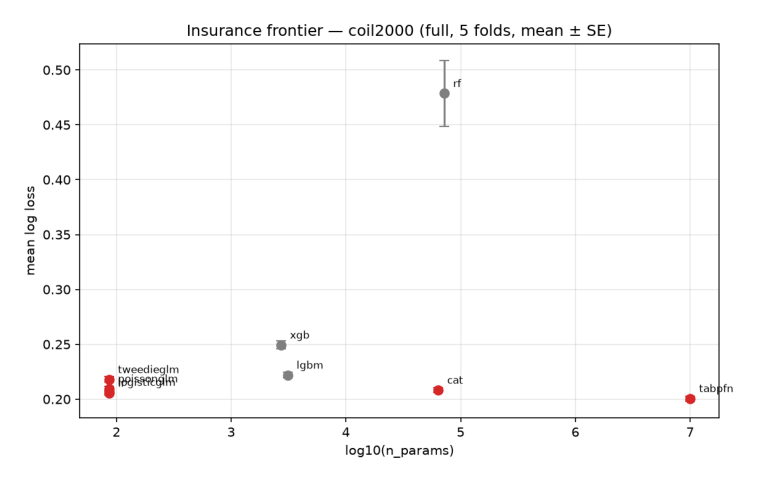

In [4]:
# The frontier plot (x = log10(n_params), y = mean log loss ± SE; red = on frontier).
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
img = mpimg.imread(ROOT / "scripts/eval/insurance_benchmark_v1/frontier_plot_coil2000.png")
plt.figure(figsize=(11, 6))
plt.imshow(img); plt.axis("off"); plt.show()

## How to extend this to the full suite

- **All 6 classification datasets:** drop the dataset argument —
  `python scripts/eval/insurance_benchmark_v1/run_frontier_benchmark.py --pr-auc` (hours; do it overnight).
- **Regression/frequency axis (§14.8):** `--regression` — same protocol, RMSE / Poisson deviance, 5-fold KFold.
- **Without clobbering canonical results:** `--seed 7` writes `frontier_results_*_seed7.csv`. Seed-stability
  testing is part of the protocol (§14.12 used seeds 7/42/123).

**Reading the table:** `on_frontier=yes` = not dominated under the D3 beyond-SE rule
(dominated iff some method with strictly fewer params has `mean_B + SE_B < mean_A − SE_A`).
On this dataset TabPFN should be log-loss best with the GLM family also on the frontier —
the master report's most robust result (S11/S12 of the knowledge path).

**Version honesty:** every number here is stamped to `model_path="v3_default"` + tabpfn-client 0.3.3.
If either drifts, master-report §15 requires a re-test before trusting the verdict — see also the
sweep-reuse caveat (the frontier reuses `home_turf_sweep_results.csv` rows on 3 datasets).